# DNN model

## Notebook set-up

In [ ]:
# Set notebook root to project root
from helper_functions import set_project_root
set_project_root()

# Silence tensorflow, except for errors
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Run on the GTX1080 GPU - fastest single worker/small memory performance
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

# Standard library imports
import pickle
import time
import types
from pathlib import Path

# Third party imports
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import tensorflow as tf
from scipy.interpolate import griddata

# Local imports
import configuration as config
from ariel_data_preprocessing.difference_pair_generator_functions import make_training_datasets

# Make sure the figures directory exists
figures_dir = f'{config.FIGURES_DIRECTORY}/model_training'
Path(figures_dir).mkdir(parents=True, exist_ok=True)

# Make sure models directory exists
Path(config.MODELS_DIRECTORY).mkdir(parents=True, exist_ok=True)

Working directory: /mnt/arkk/kaggle/ariel-data-challenge


## 1. Hyperparameter optimization results

### 1.1. Load Optuna study results

In [ ]:
loaded_study = optuna.load_study(
    study_name='dnn_optimization.1',
    storage=f'postgresql://{config.USER}:{config.PASSWD}@{config.HOST}:{config.PORT}/{config.STUDY_NAME}'
)

results_df = loaded_study.trials_dataframe()
results_df = results_df[results_df['state'] == 'COMPLETE'] # Only keep completed trials
results_df = results_df[results_df['value'] < 0.02] # Filter out extreme high loss values
results_df.sort_values('value', ascending=True, inplace=True)

param_columns = [
    'params_learning_rate',
    'params_hidden_layers',
    'params_first_layer_dense_units',
    'params_dense_units_factor',
    'params_l_one',
    'params_l_two',
    'params_beta_one',
    'params_beta_two',
    'params_weight_decay'
]

categorical_params = [
    'params_hidden_layers', 'params_smoothing_window','params_amsgrad', 'params_standardize_wavelengths', 'params_use_ema'
]

results_df.head()

,number,value,datetime_start,datetime_complete,duration,params_amsgrad,params_beta_one,params_beta_two,params_dense_units_factor,params_first_layer_dense_units,params_hidden_layers,params_l_one,params_l_two,params_learning_rate,params_smoothing_window,params_standardize_wavelengths,params_use_ema,params_weight_decay,state
867,867,0.000056,2025-09-24 04:04:27.853353,2025-09-24 04:05:30.316323,0 days 00:01:02.462970,False,0.803283,0.836408,1.820069,96.0,10.0,0.853400,0.376272,0.000370,10.0,False,True,0.062300,COMPLETE
966,966,0.000062,2025-09-24 05:03:34.503123,2025-09-24 05:04:06.426082,0 days 00:00:31.922959,False,0.739127,0.953599,1.842705,98.0,4.0,0.323102,0.859851,0.000859,10.0,True,False,0.034629,COMPLETE
336,336,0.000070,2025-09-24 01:21:44.937768,2025-09-24 01:22:15.963444,0 days 00:00:31.025676,False,0.776628,0.622729,2.433576,128.0,4.0,0.334113,0.344788,0.000480,20.0,False,False,0.081030,COMPLETE
206,206,0.000088,2025-09-24 01:00:08.698991,2025-09-24 01:00:40.507033,0 days 00:00:31.808042,False,0.832173,0.650029,1.887712,91.0,4.0,0.115658,0.407454,0.000187,10.0,False,False,0.014668,COMPLETE
1070,1070,0.000100,2025-09-24 06:37:39.544137,2025-09-24 06:38:11.267522,0 days 00:00:31.723385,False,0.807067,0.733751,2.409853,105.0,2.0,0.345238,0.387024,0.000176,10.0,False,False,0.068055,COMPLETE


In [35]:
results_df[param_columns + ['value']].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
params_learning_rate,1101.0,0.000654,0.000307,0.000005,0.000397,0.000771,0.000922,0.001000
params_hidden_layers,1101.0,4.913715,2.605728,2.000000,4.000000,4.000000,6.000000,10.000000
params_first_layer_dense_units,1101.0,88.729337,21.275367,16.000000,87.000000,94.000000,100.000000,128.000000
params_dense_units_factor,1101.0,2.064347,0.380548,1.100511,1.807147,2.027099,2.356041,2.999085
params_l_one,1101.0,0.368501,0.204522,0.002080,0.254524,0.334770,0.407794,0.999912
params_l_two,1101.0,0.641479,0.283305,0.000341,0.370366,0.705196,0.914586,0.999870
params_beta_one,1101.0,0.761329,0.084742,0.502673,0.701537,0.776628,0.822386,0.991961
params_beta_two,1101.0,0.772915,0.140675,0.500266,0.652542,0.772192,0.915272,0.999804
params_weight_decay,1101.0,0.047287,0.023731,0.000048,0.025531,0.050628,0.067588,0.099260
value,1101.0,0.006072,0.004593,0.000056,0.002269,0.005060,0.008648,0.019538


### 1.2. Validation loss distribution

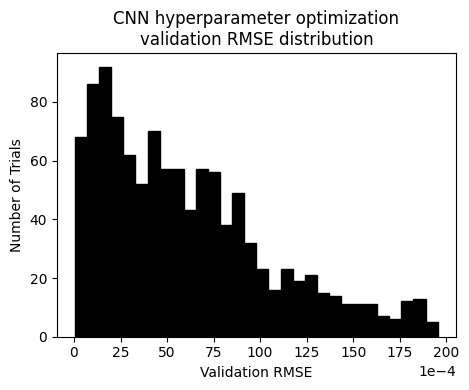

In [36]:
plt.figure(figsize=(config.STD_FIG_WIDTH/1.25, config.STD_FIG_WIDTH/1.5))
plt.title('CNN hyperparameter optimization\nvalidation RMSE distribution')
plt.hist(
    results_df['value'],
    bins=30,
    color='black',
    edgecolor='black'
)
plt.xlabel('Validation RMSE')
plt.ylabel('Number of Trials')
plt.ticklabel_format(axis='x', style='sci', scilimits=(-4, -4))
# plt.yscale('log')
plt.tight_layout()

# Save the figure
plt.savefig(
    f'{figures_dir}/03.4.1-validation_RMSE_distribution.jpg',
    dpi=config.STD_FIG_DPI,
    bbox_inches='tight'
)


### 1.3. Hyperparameter sampling distributions

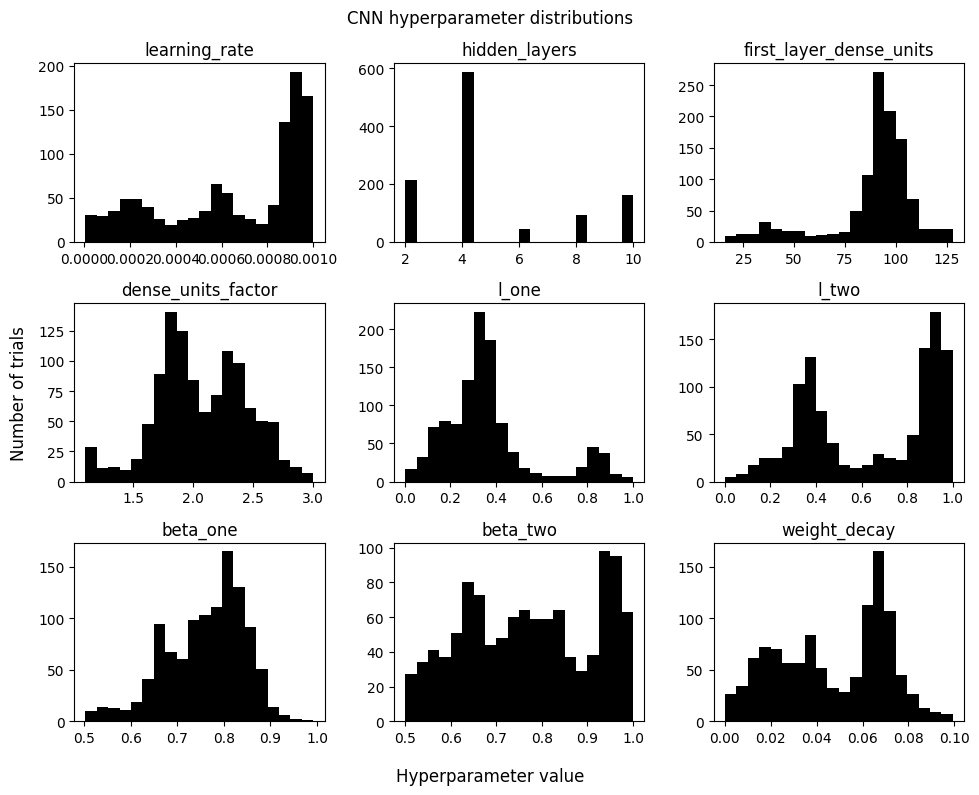

In [37]:
fig, axs = plt.subplots(3, 3, figsize=(10, 8))
axs = axs.flatten()

fig.suptitle('CNN hyperparameter distributions')
fig.supxlabel('Hyperparameter value')
fig.supylabel('Number of trials')

for i, param in enumerate(param_columns):
    axs[i].set_title(param.replace('params_', ''))
    axs[i].hist(
        results_df[param],
        bins=20,
        color='black'
    )

fig.tight_layout()

# Save the figure
plt.savefig(
    f'{figures_dir}/03.4.2-hyperparameter_distributions.jpg',
    dpi=config.STD_FIG_DPI,
    bbox_inches='tight'
)

### 1.4. Hyperparameter heatmap matrix

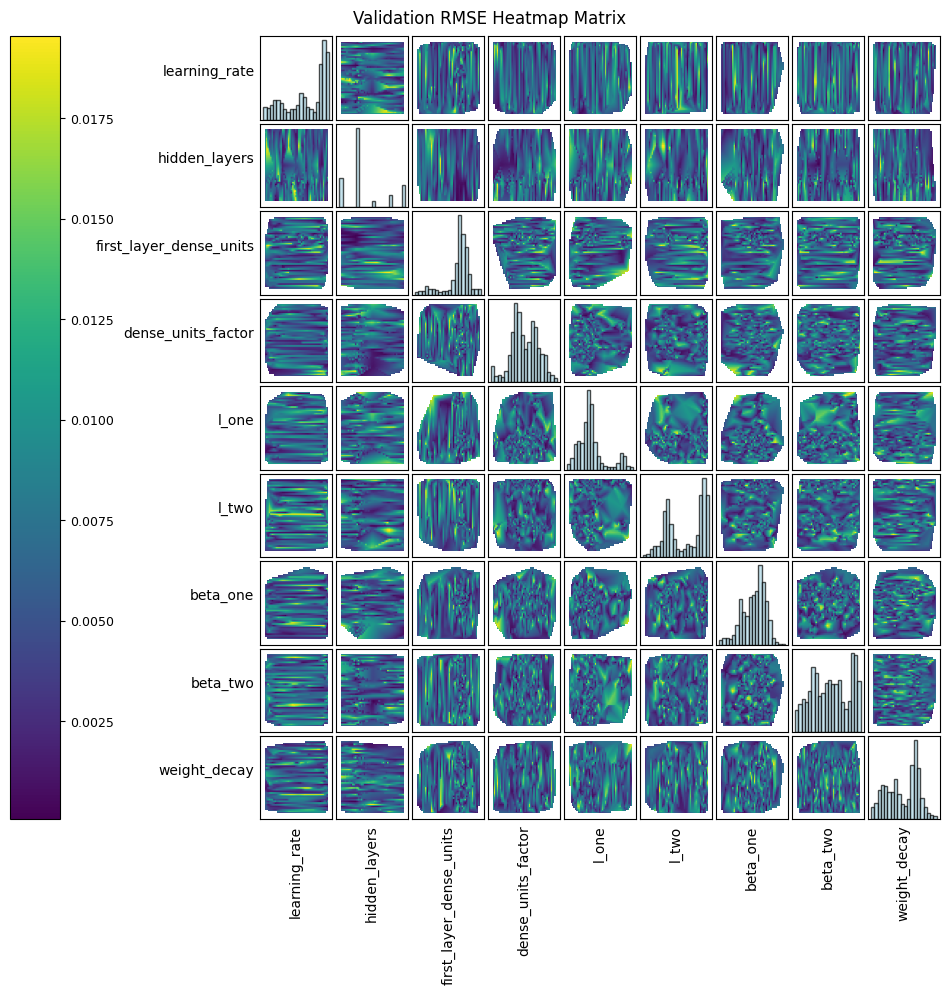

In [38]:
# Create a figure with subplots for the heatmap matrix
n_params = len(param_columns)
fig, axes = plt.subplots(n_params, n_params, figsize=(10, 9))

# Get the range of validation loss values for consistent color scaling
vmin, vmax = results_df['value'].min(), results_df['value'].max()

# Create the heatmap matrix
for i, param_y in enumerate(param_columns):
    for j, param_x in enumerate(param_columns):
        ax = axes[i, j]
        
        if i == j:

            # For diagonal elements, show parameter distribution as histogram
            ax.hist(
                results_df[param_x],
                bins=20,
                alpha=0.7,
                color='lightblue',
                edgecolor='black'
            )
            
            # Configure tick labels and marks: only show for bottom row (x) and first column (y)
            if j == 0:  # Left edge
                ax.set_ylabel(param_y.replace('params_', ''), rotation='horizontal', ha='right')

            if i == n_params - 1:  # Bottom edge
                ax.set_xlabel(param_x.replace('params_', ''), rotation='vertical')

            # Hide all tick labels and marks
            ax.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False, top=False, right=False)

        else:
            # Create interpolated heatmap of validation loss
            x_data = results_df[param_x].values
            y_data = results_df[param_y].values
            z_data = results_df['value'].values
            
            # Create a regular grid for interpolation
            x_min, x_max = x_data.min(), x_data.max()
            y_min, y_max = y_data.min(), y_data.max()
            
            # Add small margins to avoid edge effects
            x_margin = (x_max - x_min) * 0.05
            y_margin = (y_max - y_min) * 0.05
            
            x_grid = np.linspace(x_min - x_margin, x_max + x_margin, 50)
            y_grid = np.linspace(y_min - y_margin, y_max + y_margin, 50)
            X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
            
            # Interpolate using griddata
            Z_interp = griddata(
                (x_data, y_data), z_data, (X_grid, Y_grid), 
                method='linear', fill_value=np.nan
            )
            
            # Standardize the heatmap using its own min/max values
            z_min_local = np.nanmin(Z_interp)
            z_max_local = np.nanmax(Z_interp)
            
            # Create the interpolated heatmap with individual scaling
            im = ax.imshow(Z_interp, origin='lower', aspect='auto', 
                cmap='viridis', vmin=z_min_local, vmax=z_max_local,
            )
            
            # Set labels only for edge subplots to avoid clutter
            if j == 0:  # Left edge
                ax.set_ylabel(param_y.replace('params_', ''), rotation='horizontal', ha='right')

            if i == n_params - 1:  # Bottom edge
                ax.set_xlabel(param_x.replace('params_', ''), rotation='vertical')

            # Hide all tick labels and marks
            ax.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False, top=False, right=False)

# Add a single colorbar to the left of the figure showing the global range
# Note: Individual heatmaps are standardized to their own ranges
cbar_ax = fig.add_axes([0.02, 0.08, 0.05, 0.87])  # [left, bottom, width, height]

# Create a dummy mappable for the global colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(norm=norm, cmap='viridis')
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.ax.tick_params(labelsize=9)

# Adjust layout to make room for the colorbar
plt.subplots_adjust(left=0.27, right=0.95, top=0.95, bottom=0.08, hspace=0.05, wspace=0.05)

# Add a main title
fig.suptitle(
    'Validation RMSE Heatmap Matrix'
)

# Save the figure
plt.savefig(
    f'{figures_dir}/03.4.3-hyperparameter_validation_RMSE_heatmaps.jpg',
    dpi=config.STD_FIG_DPI,
    bbox_inches='tight'
)

plt.show()

## 2. Long training run

### 2.1. Initialize data generators

In [84]:
sample_size = 100
smoothing_window = 80

training_dataset, validation_dataset, evaluation_dataset = make_training_datasets(
    data_file=f'{config.PROCESSED_DATA_DIRECTORY}/train-1100_smoothing-10-20-40-80-160.h5',
    sample_size=sample_size,
    smoothing_window=smoothing_window,
    standardize_wavelengths=False
)

### 2.2. Model definition

In [85]:
true_spectra = pd.read_csv(f'{config.RAW_DATA_DIRECTORY}/train.csv')
true_spectra.drop('planet_id', axis=1, inplace=True)
true_spectra = true_spectra.to_numpy()
print(f'Dataset wide average spectral intensity: {np.mean(true_spectra):.6f} +/- {np.std(true_spectra):.6f}')

Dataset wide average spectral intensity: 0.014689 +/- 0.010661


In [86]:
def dnn(**hyperparameters) -> tf.keras.Model:

    '''Builds the deep neural network regression model'''

    hyperparameters = types.SimpleNamespace(**hyperparameters)

    # Set-up the L1L2 for the dense layers
    regularizer = tf.keras.regularizers.L1L2(
        l1=hyperparameters.l1,
        l2=hyperparameters.l2
    )

    # Define the model layers in order
    model = [tf.keras.layers.Input((config.WAVELENGTHS))]

    dense_units = hyperparameters.first_layer_dense_units
    
    for _ in range(int(hyperparameters.hidden_layers // 2)):
        model.append(
            tf.keras.layers.Dense(
                dense_units,
                kernel_initializer='he_uniform',
                kernel_regularizer=regularizer,
                bias_initializer=tf.keras.initializers.Constant(0.1),
                activation='relu',
            )
        )

        dense_units *= hyperparameters.dense_units_factor
        dense_units = int(dense_units)

    for _ in range(int(hyperparameters.hidden_layers // 2)):
        model.append(
            tf.keras.layers.Dense(
                dense_units,
                kernel_initializer='he_uniform',
                kernel_regularizer=regularizer,
                bias_initializer=tf.keras.initializers.Constant(0.1),
                activation='relu',
            )
        )

        dense_units /= hyperparameters.dense_units_factor
        dense_units = int(dense_units)

    model.append(
        tf.keras.layers.Dense(
            config.WAVELENGTHS,
            kernel_initializer=tf.keras.initializers.GlorotNormal(),
            bias_initializer=tf.keras.initializers.Constant(0.014689),
            activation='linear'
        )
    )

    model = tf.keras.Sequential(model)

    # Define the optimizer
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=hyperparameters.learning_rate,
        beta_1=hyperparameters.beta_one,
        beta_2=hyperparameters.beta_two,
        amsgrad=hyperparameters.amsgrad,
        weight_decay=hyperparameters.weight_decay,
        use_ema=hyperparameters.use_ema
    )

    # Compile the model
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.MeanSquaredError(name='MSE'),
        metrics=[tf.keras.metrics.RootMeanSquaredError(name='RMSE')]
    )

    return model

In [87]:
hyperparameters = {
    'learning_rate': 0.0009881367548452633,
    'l1': 0.949150603373996,
    'l2': 0.9896817166346684,
    'hidden_layers': 2,
    'first_layer_dense_units': 67,
    'dense_units_factor': 2.5041412317794784,
    'beta_one': 0.7466158935931395,
    'beta_two': 0.8479321433181256,
    'amsgrad': True,
    'weight_decay': 0.056802767080261975,
    'use_ema': False
}

model = dnn(**hyperparameters)
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_37 (Dense)            (None, 67)                19028     
                                                                 
 dense_38 (Dense)            (None, 167)               11356     
                                                                 
 dense_39 (Dense)            (None, 283)               47544     
                                                                 
Total params: 77,928
Trainable params: 77,928
Non-trainable params: 0
_________________________________________________________________


### 2.3. Single training run

In [88]:
batch_size = 1
epochs = 1000
steps = 100

# Note: it takes 550 epochs to see every planet in the training set once

total_ksteps = 1000 * (steps * epochs * batch_size) // 1000
n_params = np.sum([tf.keras.backend.count_params(p) for p in model.trainable_weights]) / 1000

model_save_file = f'{config.MODELS_DIRECTORY}/ariel_dnn-{n_params}k-{total_ksteps}ksteps-tf2.11.keras'
training_results_save_file = f'{config.MODELS_DIRECTORY}/ariel_dnn-{n_params}k-{total_ksteps}ksteps.pkl'

if Path(model_save_file).exists() and Path(training_results_save_file).exists():

    print(f'Found existing model for {total_ksteps} ksteps, skipping training.')

    # Load the existing model
    model = tf.keras.models.load_model(model_save_file)

    # Load existing training results
    with open(training_results_save_file, 'rb') as input_file:
        training_results = pickle.load(input_file)

else:

  print(f'Training model for {total_ksteps} ksteps')
  start_time = time.time()

  training_results = model.fit(
    training_dataset.batch(batch_size),
    validation_data=validation_dataset.batch(batch_size),
    epochs=epochs,
    steps_per_epoch=steps,
    validation_steps=10 * sample_size, # Evaluate on 10 planets
    verbose=1
  )

  print(f'Training complete in {(time.time() - start_time)/60:.1f} minutes')
  model.save(model_save_file)

  with open(training_results_save_file, 'wb') as output_file:
      pickle.dump(training_results, output_file)

Training model for 100000 ksteps
Epoch 1/1000


100/100 [==============================] - 6s 40ms/step - loss: 4506.6250 - RMSE: 37.0800 - val_loss: 9795.3906 - val_RMSE: 82.2306
Epoch 2/1000
100/100 [==============================] - 4s 40ms/step - loss: 3462.1348 - RMSE: 22.0865 - val_loss: 4975.0420 - val_RMSE: 45.3224
Epoch 3/1000
100/100 [==============================] - 3s 34ms/step - loss: 4739.5293 - RMSE: 43.0216 - val_loss: 3335.0845 - val_RMSE: 21.7906
Epoch 4/1000
100/100 [==============================] - 3s 35ms/step - loss: 3117.4646 - RMSE: 16.7678 - val_loss: 3408.2798 - val_RMSE: 24.4083
Epoch 5/1000
100/100 [==============================] - 4s 35ms/step - loss: 3066.9519 - RMSE: 16.6350 - val_loss: 3360.4363 - val_RMSE: 24.3411
Epoch 6/1000
100/100 [==============================] - 4s 35ms/step - loss: 3077.6648 - RMSE: 18.1965 - val_loss: 3173.6567 - val_RMSE: 21.1800
Epoch 7/1000
100/100 [==============================] - 3s 34ms/step - loss: 2922.3984 - RMSE: 14.7524 - val_loss: 2931.9292 - val_RMSE: 15.733

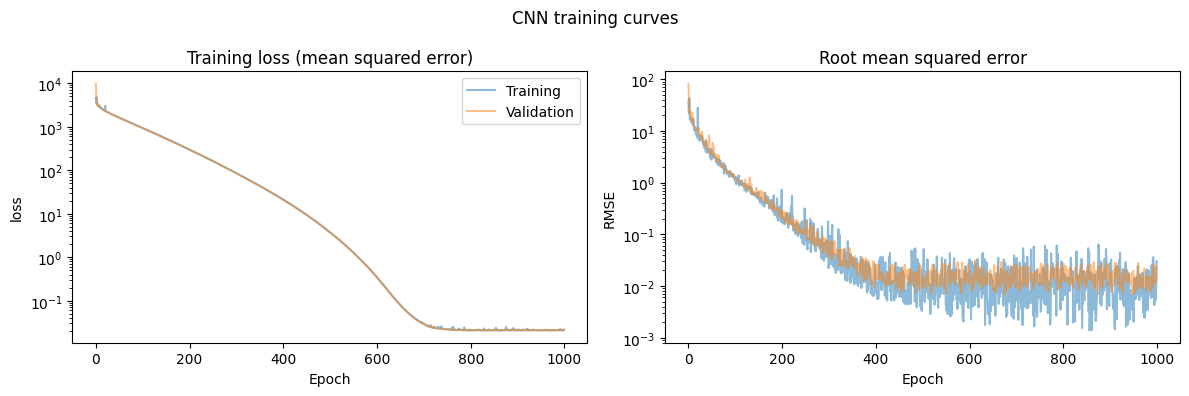

In [93]:
# Set-up a 1x2 figure for accuracy and binary cross-entropy
fig, axs=plt.subplots(1,2, figsize=(12,4))

# Add the main title
fig.suptitle('CNN training curves', size='large')

# Plot training and validation loss
axs[0].set_title('Training loss (mean squared error)')
axs[0].plot(np.array(training_results.history['loss']), alpha=0.5, label='Training')
axs[0].plot(np.array(training_results.history['val_loss']), alpha=0.5, label='Validation')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('loss')
# axs[0].set_ylim(21, 25)
axs[0].set_yscale('log')
axs[0].legend(loc='upper right')

# Plot training and validation RMSE
axs[1].set_title('Root mean squared error')
axs[1].plot(training_results.history['RMSE'], alpha=0.5, label='Training')
axs[1].plot(training_results.history['val_RMSE'], alpha=0.5, label='Validation')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('RMSE')
# axs[2].set_ylim(top=0.014)
axs[1].set_yscale('log')

# Show the plot
fig.tight_layout()
fig.savefig(
    f'{figures_dir}/03.4.1-ariel_dnn_training_curves_{n_params}k-{total_ksteps}ksteps.jpg',
    dpi=config.STD_FIG_DPI,
    bbox_inches='tight'
)

## 3. Model evaluation (validation set)

### 3.1. Evaluation dataset

In [90]:
planets = 10

evaluation_data = evaluation_dataset.take(planets)

signals = np.array([element[0].numpy() for element in evaluation_data])
spectra = np.array([element[1].numpy() for element in evaluation_data])

print(f'Signals shape: {signals.shape}')
print(f'Spectra shape: {spectra.shape}')

Signals shape: (10, 100, 283)
Spectra shape: (10, 100, 283)


### 3.2. Predictions

In [91]:
spectrum_predictions = []

for planet in signals:
    spectrum_predictions.append(model.predict(planet, batch_size=100, verbose=0))

spectrum_predictions = np.array(spectrum_predictions)
spectrum_predictions_avg = np.mean(spectrum_predictions, axis=1).flatten()
spectrum_predictions = spectrum_predictions.flatten()
reference_spectra = spectra[:,0,:].flatten()
spectra = spectra.flatten()

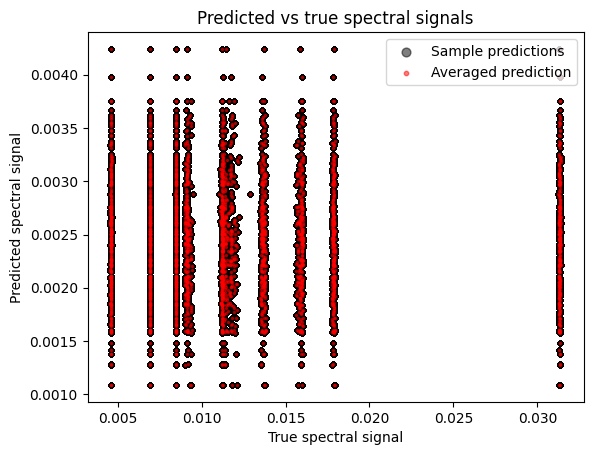

In [92]:
plt.title('Predicted vs true spectral signals')
plt.scatter(spectra, spectrum_predictions, s=10, alpha=0.5, color='black', label='Sample predictions')
plt.scatter(reference_spectra, spectrum_predictions_avg, s=2.5, alpha=0.5, color='red', label='Averaged prediction')
plt.xlabel('True spectral signal')
plt.ylabel('Predicted spectral signal')
plt.legend(loc='best', markerscale=2)

plt.savefig(
    f'{figures_dir}/03.4.5-ariel_dnn_predicted_vs_true_spectra-{n_params}k-{total_ksteps}ksteps.jpg',
    dpi=config.STD_FIG_DPI,
    bbox_inches='tight'
)

plt.show()